ESERCIZIO
Modifica il codice della lezione 
Stampa delle immagni generate ogni 3 epoche di addestramento
Visualizza come cambia il risultato della generazione al variare di beta.

Inizio addestramento...


Epoca 1/15: 100%|██████████| 469/469 [00:11<00:00, 41.45it/s, BCE=234.35, Beta=0.00, KLD=281.88]


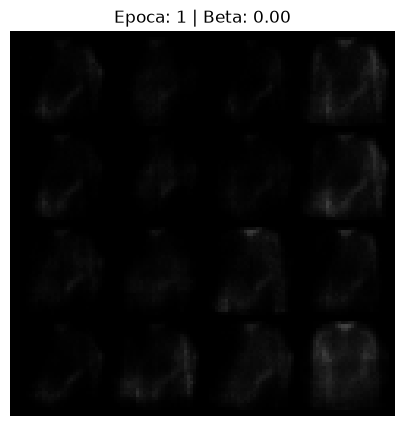

Epoca 3/15: 100%|██████████| 469/469 [00:11<00:00, 40.31it/s, BCE=230.62, Beta=0.27, KLD=31.18]


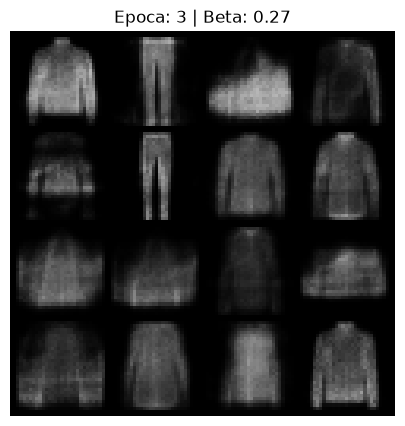

Epoca 6/15: 100%|██████████| 469/469 [00:10<00:00, 42.79it/s, BCE=238.95, Beta=0.67, KLD=17.84]


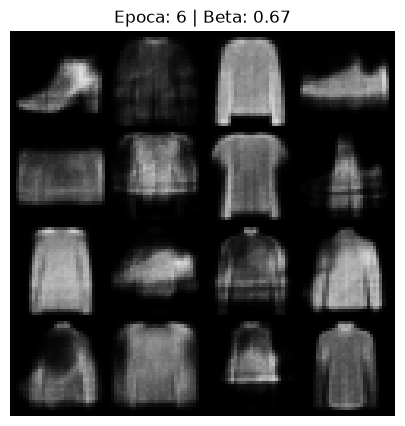

Epoca 9/15: 100%|██████████| 469/469 [00:10<00:00, 43.21it/s, BCE=230.13, Beta=1.00, KLD=15.13]


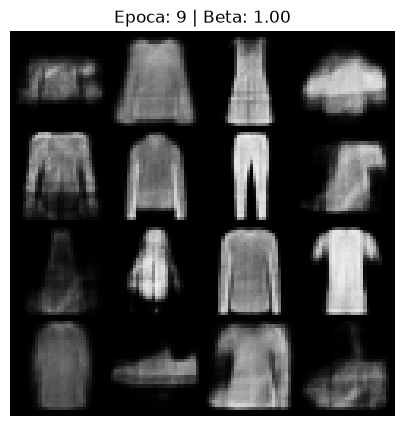

Epoca 12/15: 100%|██████████| 469/469 [00:11<00:00, 42.19it/s, BCE=229.72, Beta=1.00, KLD=14.27]


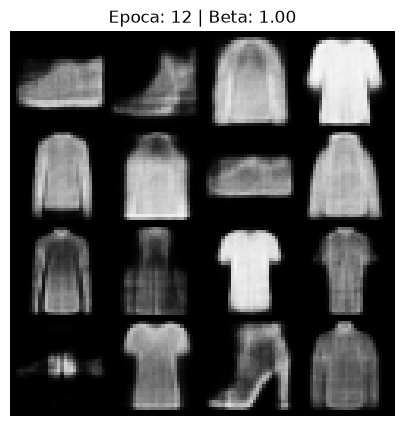

Epoca 15/15: 100%|██████████| 469/469 [00:11<00:00, 40.42it/s, BCE=221.17, Beta=1.00, KLD=15.62]


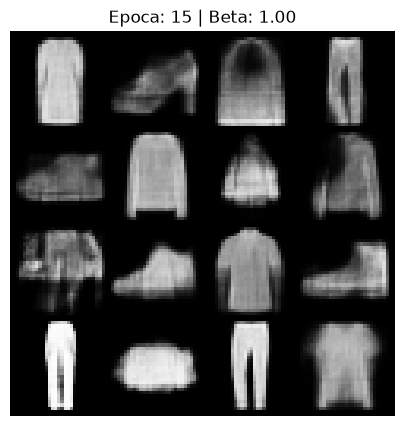

: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 32 
epochs = 15
batch_size = 128
lr = 1e-3

transform = transforms.Compose([transforms.ToTensor()])
train_loader = DataLoader(
    datasets.FashionMNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

# --- ARCHITETTURA DEL MODELLO VAE ---
class FashionVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU(),
            nn.Linear(400, 200),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(200, latent_dim)
        self.fc_logvar = nn.Linear(200, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 200),
            nn.ReLU(),
            nn.Linear(200, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x.view(-1, 784))
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

def loss_function(recon_x, x, mu, logvar, beta):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD, BCE, KLD

# --- FUNZIONE PER MOSTRARE LE IMMAGINI GENERATE ---
def show_generated_images(model, epoch, beta):
    model.eval()
    with torch.no_grad():
        # Creiamo un set fisso di rumore per vedere come evolve la stessa "idea" di immagine
        sample = torch.randn(16, latent_dim).to(device)
        sample = model.decoder(sample).cpu()
        grid = utils.make_grid(sample.view(16, 1, 28, 28), nrow=4)
        
        plt.figure(figsize=(5, 5))
        plt.imshow(grid.permute(1, 2, 0))
        plt.title(f"Epoca: {epoch} | Beta: {beta:.2f}")
        plt.axis('off')
        plt.show()

# --- PROCESSO DI ADDESTRAMENTO ---
model = FashionVAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

print("Inizio addestramento...")

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0
    
    # Beta Annealing: da 0 a 1 nel corso delle epoche
    beta = min(1.0, (epoch - 1) / (epochs * 0.5))
    
    pbar = tqdm(train_loader, desc=f"Epoca {epoch}/{epochs}")
    for data, _ in pbar:
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar = model(data)
        loss, bce, kld = loss_function(recon_batch, data, mu, logvar, beta)
        
        loss.backward()
        optimizer.step()
        
        pbar.set_postfix(BCE=f"{bce.item()/len(data):.2f}", KLD=f"{kld.item()/len(data):.2f}", Beta=f"{beta:.2f}")

    # --- MODIFICA: Stampa ogni 3 epoche ---
    if epoch % 3 == 0 or epoch == 1:
        show_generated_images(model, epoch, beta)